In [ ]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Mengkoneksikan Colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
#Menentukan lokasi path dataset
path = "/content/gdrive/MyDrive/Dataset/"

In [ ]:
#Menetapkan jumlah maksimum baris dan kolom yang ditampilkan
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
#Membaca file CSV ke dataframe
df = pd.read_csv(path + 'Travel details dataset.csv')
#Menampilkan isi dataframe
df

,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
0,1,"London, UK",5/1/2023,5/8/2023,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600
1,2,"Phuket, Thailand",6/15/2023,6/20/2023,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500
2,3,"Bali, Indonesia",7/1/2023,7/8/2023,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700
3,4,"New York, USA",8/15/2023,8/29/2023,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000
4,5,"Tokyo, Japan",9/10/2023,9/17/2023,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200
5,6,"Paris, France",10/5/2023,10/10/2023,5.0,Michael Brown,42.0,Male,American,Hotel,1500,Flight,800
6,7,"Sydney, Australia",11/20/2023,11/30/2023,10.0,Emily Davis,33.0,Female,Australian,Hostel,500,Flight,1200
7,8,"Rio de Janeiro, Brazil",1/5/2024,1/12/2024,7.0,Lucas Santos,25.0,Male,Brazilian,Airbnb,900,Flight,600
8,9,"Amsterdam, Netherlands",2/14/2024,2/21/2024,7.0,Laura Janssen,31.0,Female,Dutch,Hotel,1200,Train,200
9,10,"Dubai, United Arab Emirates",3/10/2024,3/17/2024,7.0,Mohammed Ali,39.0,Male,Emirati,Resort,2500,Flight,800







**Data Understanding & Explorasi Data**

In [ ]:
#Mencetak informasi tentang tipe data dan jumlah data pada setiap kolom dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Trip ID               139 non-null    int64  
 1   Destination           137 non-null    object 
 2   Start date            137 non-null    object 
 3   End date              137 non-null    object 
 4   Duration (days)       137 non-null    float64
 5   Traveler name         137 non-null    object 
 6   Traveler age          137 non-null    float64
 7   Traveler gender       137 non-null    object 
 8   Traveler nationality  137 non-null    object 
 9   Accommodation type    137 non-null    object 
 10  Accommodation cost    137 non-null    object 
 11  Transportation type   136 non-null    object 
 12  Transportation cost   136 non-null    object 
dtypes: float64(2), int64(1), object(10)
memory usage: 14.2+ KB


In [ ]:
#Mencetak statistik deskriptif untuk kolom numerik pada dataframe
df.describe()

,Trip ID,Duration (days),Traveler age
count,139.000000,137.000000,137.000000
mean,70.000000,7.605839,33.175182
std,40.269923,1.601276,7.145441
min,1.000000,5.000000,20.000000
25%,35.500000,7.000000,28.000000
50%,70.000000,7.000000,31.000000
75%,104.500000,8.000000,38.000000
max,139.000000,14.000000,60.000000


**Cleaning Data**
- Melihat apakah ada duplikat
- Menyesuaikan nama dan tipe data kolom
- mengisi missing value
- menghapus kolom yang nilai missing value nya melebihi 60% dan tidak diperlukan

**df[df.duplicated(['Trip ID'],keep=False)]**

mengecek apakah ada baris yang duplikat

In [ ]:
#Mengecek keberadaan baris duplikat berdasarkan kolom 'Trip ID'
df[df.duplicated(['Trip ID'],keep=False)]

,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost


**df.isnull( ).sum( ):**

Menghitung jumlah nilai yang hilang di setiap kolom

In [ ]:
#Mencetak jumlah nilai kosong (missing value) per kolom
df.isnull().sum()

Trip ID                 0
Destination             2
Start date              2
End date                2
Duration (days)         2
Traveler name           2
Traveler age            2
Traveler gender         2
Traveler nationality    2
Accommodation type      2
Accommodation cost      2
Transportation type     3
Transportation cost     3
dtype: int64

**df.nunique( ):**

Jumlah elemen unik dalam objek. Menghitung jumlah entri unik pada kolom atau baris.


In [ ]:
#Mencetak jumlah unik dari setiap kolom
df.nunique()

Trip ID                 139
Destination              59
Start date              111
End date                125
Duration (days)           9
Traveler name           109
Traveler age             29
Traveler gender           2
Traveler nationality     41
Accommodation type        8
Accommodation cost       53
Transportation type       9
Transportation cost      48
dtype: int64

**Menyesuaikan tipe data setiap kolom**

In [ ]:
#Mengubah tipe data kolom 'Start date' dan 'End date' menjadi datetime
df['Start date'] = pd.to_datetime(df['Start date'])
df['End date'] = pd.to_datetime(df['End date'])

In [ ]:
#Mengubah tipe data kolom 'Traveler age' menjadi integer
df['Traveler age'] = pd.to_numeric(df['Traveler age']).astype('Int64')

In [ ]:
#Mengubah tipe data kolom 'Duration (days)' menjadi integer
df['Duration (days)'] = pd.to_numeric(df['Duration (days)']).astype('Int64')

In [ ]:
#Menghilangkan karakter selain angka pada kolom 'Accommodation cost' dan 'Transportation cost'
df['Accommodation cost'] = df['Accommodation cost'].str.replace('USD', '')
df['Accommodation cost'] = df['Accommodation cost'].str.replace('$', '')
df['Transportation cost'] = df['Transportation cost'].str.replace('$', '')
df['Transportation cost'] = df['Transportation cost'].str.replace('USD', '')
df['Accommodation cost'] = df['Accommodation cost'].str.replace(',','')
df['Transportation cost'] = df['Transportation cost'].str.replace(',','')
df['Accommodation cost'] = df['Accommodation cost'].str.replace('USD','')
df['Transportation cost'] = df['Transportation cost'].str.replace('USD','')

In [ ]:
#Mengubah tipe data kolom 'Accommodation cost' dan 'Transportation cost' menjadi integer
df['Accommodation cost'] = pd.to_numeric(df['Accommodation cost']).astype('Int64')
df['Transportation cost'] = pd.to_numeric(df['Transportation cost']).astype('Int64')

**Penghapusan baris dengan Trip ID 72 dan 128 dari DataFrame**

Alasannya karena mengandung banyak nilai NaN atau kosong di sebagian besar kolomnya, sehingga tidak memberikan informasi yang signifikan untuk analisis lebih lanjut.

In [ ]:
#Menghapus baris Trip ID 72 dan 128
df = df[~df['Trip ID'].isin([72, 128])]
df

,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
0,1,"London, UK",2023-05-01,2023-05-08,7,John Smith,35,Male,American,Hotel,1200,Flight,600
1,2,"Phuket, Thailand",2023-06-15,2023-06-20,5,Jane Doe,28,Female,Canadian,Resort,800,Flight,500
2,3,"Bali, Indonesia",2023-07-01,2023-07-08,7,David Lee,45,Male,Korean,Villa,1000,Flight,700
3,4,"New York, USA",2023-08-15,2023-08-29,14,Sarah Johnson,29,Female,British,Hotel,2000,Flight,1000
4,5,"Tokyo, Japan",2023-09-10,2023-09-17,7,Kim Nguyen,26,Female,Vietnamese,Airbnb,700,Train,200
5,6,"Paris, France",2023-10-05,2023-10-10,5,Michael Brown,42,Male,American,Hotel,1500,Flight,800
6,7,"Sydney, Australia",2023-11-20,2023-11-30,10,Emily Davis,33,Female,Australian,Hostel,500,Flight,1200
7,8,"Rio de Janeiro, Brazil",2024-01-05,2024-01-12,7,Lucas Santos,25,Male,Brazilian,Airbnb,900,Flight,600
8,9,"Amsterdam, Netherlands",2024-02-14,2024-02-21,7,Laura Janssen,31,Female,Dutch,Hotel,1200,Train,200
9,10,"Dubai, United Arab Emirates",2024-03-10,2024-03-17,7,Mohammed Ali,39,Male,Emirati,Resort,2500,Flight,800


**Menampilkan nilai unik di kolom 'destination'**

In [ ]:
#Mencetak daftar Destination unik
unique_destinations = df['Destination'].unique()
print(unique_destinations)

NameError: name 'df' is not defined

In [ ]:
#Kamus untuk mencocokkan negara berdasarkan kota
city_country_dict = {
    'Paris': 'France',
    'Bali': 'Indonesia',
    'London': 'UK',
    'Tokyo': 'Japan',
    'New York': 'USA',
    'Sydney': 'Australia',
    'Rome': 'Italy',
    'Bangkok': 'Thailand',
    'Hawaii': 'USA',
    'Japan': 'Japan',
    'Thailand': 'Thailand',
    'France': 'France',
    'Australia': 'Australia',
    'Brazil': 'Brazil',
    'Greece': 'Greece',
    'Egypt': 'Egypt',
    'Mexico': 'Mexico',
    'Italy': 'Italy',
    'Spain': 'Spain',
    'Canada': 'Canada',
    'Amsterdam': 'Netherlands',
    'Seoul': 'South Korea',
    'Los Angeles': 'USA',
    'Cape Town': 'South Africa',
    'Santorini': 'Yunani',
    'Dubai': 'UEA',
    'Phnom Penh': 'Kamboja',
    'Phuket': 'Thailand',
    'Barcelona': 'Spain',
    'Rio de Janeiro': 'Brazil'
}

In [ ]:
#Fungsi untuk mengisi negara yang belum lengkap
def complete_country(destination):
    parts = destination.split(', ')
    if len(parts) == 1:
        city = parts[0]
        country = city_country_dict.get(city, '')
        if country:
            return f"{city}, {country}"
        else:
            return destination
    else:
        return destination

In [ ]:
# Melengkapi kolom 'Destination' dengan fungsi 'complete_country'
df['Destination'] = df['Destination'].apply(complete_country)

<ipython-input-2106-2c8e5ed732b5>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Destination'] = df['Destination'].apply(complete_country)


In [ ]:
#Fungsi untuk memproses kolom destinasi dan mengembalikan bagian pertama dari string destinasi (diasumsikan sebagai kota)
def process_destination(destination):
    if isinstance(destination, str):
        return destination.split(',')[0].strip()
    else:
        return destination

In [ ]:
#Menerapkan fungsi process_destination
df['Destination_City'] = df['Destination'].apply(process_destination)

<ipython-input-2108-681aa66f0063>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Destination_City'] = df['Destination'].apply(process_destination)


In [ ]:
#Membuat urutan kolom baru
new_columns = ['Trip ID', 'Destination', 'Destination_City'] + [col for col in df.columns if col not in ['Trip ID', 'Destination', 'Destination_City']]
df = df[new_columns]

In [ ]:
#Fungsi untuk memproses kolom destinasi dan mengembalikan bagian kedua dari string destinasi (diasumsikan sebagai negara)
def extract_country(destination):
    parts = destination.split(',')
    if len(parts) > 1:
        return parts[1].strip()
    else:
        return None

In [ ]:
#Menerapkan fungsi extract_country
df['Destination_Country'] = df['Destination'].apply(extract_country)

<ipython-input-2111-853b07f87dbc>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Destination_Country'] = df['Destination'].apply(extract_country)


In [ ]:
#Membuat urutan kolom baru
new_columns = ['Trip ID', 'Destination', 'Destination_City', 'Destination_Country'] + [col for col in df.columns if col not in ['Trip ID', 'Destination', 'Destination_City', 'Destination_Country']]
df = df[new_columns]

In [ ]:
#Filtering untuk destinasi yang sama (Roma, Italia)
rome_trips = df[df['Destination'] == 'Rome, Italy']

In [ ]:
#Menghitung nilai modus untuk kolom Transportation type dan Transportation cost
mode_transportation_type = rome_trips['Transportation type'].mode()[0]
mode_transportation_cost = rome_trips['Transportation cost'].mode()[0]

In [ ]:
#Mengisi nilai NaN pada kolom tipe transportasi dan biaya transportasi
df.loc[(df['Trip ID'] == 83) & (df['Destination'] == 'Rome, Italy'), 'Transportation type'] = mode_transportation_type
df.loc[(df['Trip ID'] == 83) & (df['Destination'] == 'Rome, Italy'), 'Transportation cost'] = mode_transportation_cost

In [ ]:
#Menampilkan isi dataframe yang sudah memproses kolom destinasi, mengisi kolom-kolom baru, dan mengisi nilai NaN pada kolom tipe transportasi dan biaya transportasi
df

,Trip ID,Destination,Destination_City,Destination_Country,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
0,1,"London, UK",London,UK,2023-05-01,2023-05-08,7,John Smith,35,Male,American,Hotel,1200,Flight,600
1,2,"Phuket, Thailand",Phuket,Thailand,2023-06-15,2023-06-20,5,Jane Doe,28,Female,Canadian,Resort,800,Flight,500
2,3,"Bali, Indonesia",Bali,Indonesia,2023-07-01,2023-07-08,7,David Lee,45,Male,Korean,Villa,1000,Flight,700
3,4,"New York, USA",New York,USA,2023-08-15,2023-08-29,14,Sarah Johnson,29,Female,British,Hotel,2000,Flight,1000
4,5,"Tokyo, Japan",Tokyo,Japan,2023-09-10,2023-09-17,7,Kim Nguyen,26,Female,Vietnamese,Airbnb,700,Train,200
5,6,"Paris, France",Paris,France,2023-10-05,2023-10-10,5,Michael Brown,42,Male,American,Hotel,1500,Flight,800
6,7,"Sydney, Australia",Sydney,Australia,2023-11-20,2023-11-30,10,Emily Davis,33,Female,Australian,Hostel,500,Flight,1200
7,8,"Rio de Janeiro, Brazil",Rio de Janeiro,Brazil,2024-01-05,2024-01-12,7,Lucas Santos,25,Male,Brazilian,Airbnb,900,Flight,600
8,9,"Amsterdam, Netherlands",Amsterdam,Netherlands,2024-02-14,2024-02-21,7,Laura Janssen,31,Female,Dutch,Hotel,1200,Train,200
9,10,"Dubai, United Arab Emirates",Dubai,United Arab Emirates,2024-03-10,2024-03-17,7,Mohammed Ali,39,Male,Emirati,Resort,2500,Flight,800


In [ ]:
#Mencetak jumlah nilai kosong (missing value) per kolom setelah semua kolom diisi
df.isnull().sum()

Trip ID                 0
Destination             0
Destination_City        0
Destination_Country     0
Start date              0
End date                0
Duration (days)         0
Traveler name           0
Traveler age            0
Traveler gender         0
Traveler nationality    0
Accommodation type      0
Accommodation cost      0
Transportation type     0
Transportation cost     0
dtype: int64

In [ ]:
#Nilai tukar USD ke IDR terupdate by Google
exchange_rate = 16356

# Konversi biaya akomodasi dan transportasi ke IDR
df['Accommodation cost (IDR)'] = df['Accommodation cost'] * exchange_rate
df['Transportation cost (IDR)'] = df['Transportation cost'] * exchange_rate


In [ ]:
#Mengubah tipe data kolom-kolom biaya ke format angka bilangan bulat
df['Accommodation cost (IDR)'] = pd.to_numeric(df['Accommodation cost (IDR)']).astype('Int64')
df['Transportation cost (IDR)'] = pd.to_numeric(df['Transportation cost (IDR)']).astype('Int64')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 137 entries, 0 to 138
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Trip ID                    137 non-null    int64         
 1   Destination                137 non-null    object        
 2   Destination_City           137 non-null    object        
 3   Destination_Country        137 non-null    object        
 4   Start date                 137 non-null    datetime64[ns]
 5   End date                   137 non-null    datetime64[ns]
 6   Duration (days)            137 non-null    Int64         
 7   Traveler name              137 non-null    object        
 8   Traveler age               137 non-null    Int64         
 9   Traveler gender            137 non-null    object        
 10  Traveler nationality       137 non-null    object        
 11  Accommodation type         137 non-null    object        
 12  Accommodation

In [ ]:
#Menampilkan isi dataframe kembali
df

,Trip ID,Destination,Destination_City,Destination_Country,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost,Accommodation cost (IDR),Transportation cost (IDR)
0,1,"London, UK",London,UK,2023-05-01,2023-05-08,7,John Smith,35,Male,American,Hotel,1200,Flight,600,19627200,9813600
1,2,"Phuket, Thailand",Phuket,Thailand,2023-06-15,2023-06-20,5,Jane Doe,28,Female,Canadian,Resort,800,Flight,500,13084800,8178000
2,3,"Bali, Indonesia",Bali,Indonesia,2023-07-01,2023-07-08,7,David Lee,45,Male,Korean,Villa,1000,Flight,700,16356000,11449200
3,4,"New York, USA",New York,USA,2023-08-15,2023-08-29,14,Sarah Johnson,29,Female,British,Hotel,2000,Flight,1000,32712000,16356000
4,5,"Tokyo, Japan",Tokyo,Japan,2023-09-10,2023-09-17,7,Kim Nguyen,26,Female,Vietnamese,Airbnb,700,Train,200,11449200,3271200
5,6,"Paris, France",Paris,France,2023-10-05,2023-10-10,5,Michael Brown,42,Male,American,Hotel,1500,Flight,800,24534000,13084800
6,7,"Sydney, Australia",Sydney,Australia,2023-11-20,2023-11-30,10,Emily Davis,33,Female,Australian,Hostel,500,Flight,1200,8178000,19627200
7,8,"Rio de Janeiro, Brazil",Rio de Janeiro,Brazil,2024-01-05,2024-01-12,7,Lucas Santos,25,Male,Brazilian,Airbnb,900,Flight,600,14720400,9813600
8,9,"Amsterdam, Netherlands",Amsterdam,Netherlands,2024-02-14,2024-02-21,7,Laura Janssen,31,Female,Dutch,Hotel,1200,Train,200,19627200,3271200
9,10,"Dubai, United Arab Emirates",Dubai,United Arab Emirates,2024-03-10,2024-03-17,7,Mohammed Ali,39,Male,Emirati,Resort,2500,Flight,800,40890000,13084800


In [ ]:
# Memindahkan kolom 'Accommodation cost (IDR)' ke sebelah kolom 'Accommodation cost (USD)'
accommodation_cost_usd_idx = df.columns.get_loc('Accommodation cost')
cols = df.columns.tolist()
cols.insert(accommodation_cost_usd_idx + 1, cols.pop(cols.index('Accommodation cost (IDR)')))
df = df[cols]

In [ ]:
# Hapus kolom biaya dalam USD
df.drop(columns=['Accommodation cost', 'Transportation cost'], inplace=True)

<ipython-input-2123-ba82be91823c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['Accommodation cost', 'Transportation cost'], inplace=True)


In [ ]:
df['Day of the week']=df['Start date'].dt.day_name()
df['Month']=df['Start date'].dt.month_name()

<ipython-input-2124-c11d721e932e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Day of the week']=df['Start date'].dt.day_name()


In [ ]:
#Menampilkan isi dataframe
df

,Trip ID,Destination,Destination_City,Destination_Country,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost (IDR),Transportation type,Transportation cost (IDR),Day of the week,Month
0,1,"London, UK",London,UK,2023-05-01,2023-05-08,7,John Smith,35,Male,American,Hotel,19627200,Flight,9813600,Monday,May
1,2,"Phuket, Thailand",Phuket,Thailand,2023-06-15,2023-06-20,5,Jane Doe,28,Female,Canadian,Resort,13084800,Flight,8178000,Thursday,June
2,3,"Bali, Indonesia",Bali,Indonesia,2023-07-01,2023-07-08,7,David Lee,45,Male,Korean,Villa,16356000,Flight,11449200,Saturday,July
3,4,"New York, USA",New York,USA,2023-08-15,2023-08-29,14,Sarah Johnson,29,Female,British,Hotel,32712000,Flight,16356000,Tuesday,August
4,5,"Tokyo, Japan",Tokyo,Japan,2023-09-10,2023-09-17,7,Kim Nguyen,26,Female,Vietnamese,Airbnb,11449200,Train,3271200,Sunday,September
5,6,"Paris, France",Paris,France,2023-10-05,2023-10-10,5,Michael Brown,42,Male,American,Hotel,24534000,Flight,13084800,Thursday,October
6,7,"Sydney, Australia",Sydney,Australia,2023-11-20,2023-11-30,10,Emily Davis,33,Female,Australian,Hostel,8178000,Flight,19627200,Monday,November
7,8,"Rio de Janeiro, Brazil",Rio de Janeiro,Brazil,2024-01-05,2024-01-12,7,Lucas Santos,25,Male,Brazilian,Airbnb,14720400,Flight,9813600,Friday,January
8,9,"Amsterdam, Netherlands",Amsterdam,Netherlands,2024-02-14,2024-02-21,7,Laura Janssen,31,Female,Dutch,Hotel,19627200,Train,3271200,Wednesday,February
9,10,"Dubai, United Arab Emirates",Dubai,United Arab Emirates,2024-03-10,2024-03-17,7,Mohammed Ali,39,Male,Emirati,Resort,40890000,Flight,13084800,Sunday,March


In [ ]:
df['Transportation type'] = df['Transportation type'].str.replace('Flight', 'Plane')

In [ ]:
df

,Trip ID,Destination,Destination_City,Destination_Country,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost (IDR),Transportation type,Transportation cost (IDR),Day of the week,Month
0,1,"London, UK",London,UK,2023-05-01,2023-05-08,7,John Smith,35,Male,American,Hotel,19627200,Plane,9813600,Monday,May
1,2,"Phuket, Thailand",Phuket,Thailand,2023-06-15,2023-06-20,5,Jane Doe,28,Female,Canadian,Resort,13084800,Plane,8178000,Thursday,June
2,3,"Bali, Indonesia",Bali,Indonesia,2023-07-01,2023-07-08,7,David Lee,45,Male,Korean,Villa,16356000,Plane,11449200,Saturday,July
3,4,"New York, USA",New York,USA,2023-08-15,2023-08-29,14,Sarah Johnson,29,Female,British,Hotel,32712000,Plane,16356000,Tuesday,August
4,5,"Tokyo, Japan",Tokyo,Japan,2023-09-10,2023-09-17,7,Kim Nguyen,26,Female,Vietnamese,Airbnb,11449200,Train,3271200,Sunday,September
5,6,"Paris, France",Paris,France,2023-10-05,2023-10-10,5,Michael Brown,42,Male,American,Hotel,24534000,Plane,13084800,Thursday,October
6,7,"Sydney, Australia",Sydney,Australia,2023-11-20,2023-11-30,10,Emily Davis,33,Female,Australian,Hostel,8178000,Plane,19627200,Monday,November
7,8,"Rio de Janeiro, Brazil",Rio de Janeiro,Brazil,2024-01-05,2024-01-12,7,Lucas Santos,25,Male,Brazilian,Airbnb,14720400,Plane,9813600,Friday,January
8,9,"Amsterdam, Netherlands",Amsterdam,Netherlands,2024-02-14,2024-02-21,7,Laura Janssen,31,Female,Dutch,Hotel,19627200,Train,3271200,Wednesday,February
9,10,"Dubai, United Arab Emirates",Dubai,United Arab Emirates,2024-03-10,2024-03-17,7,Mohammed Ali,39,Male,Emirati,Resort,40890000,Plane,13084800,Sunday,March


**Visualisasi Data**

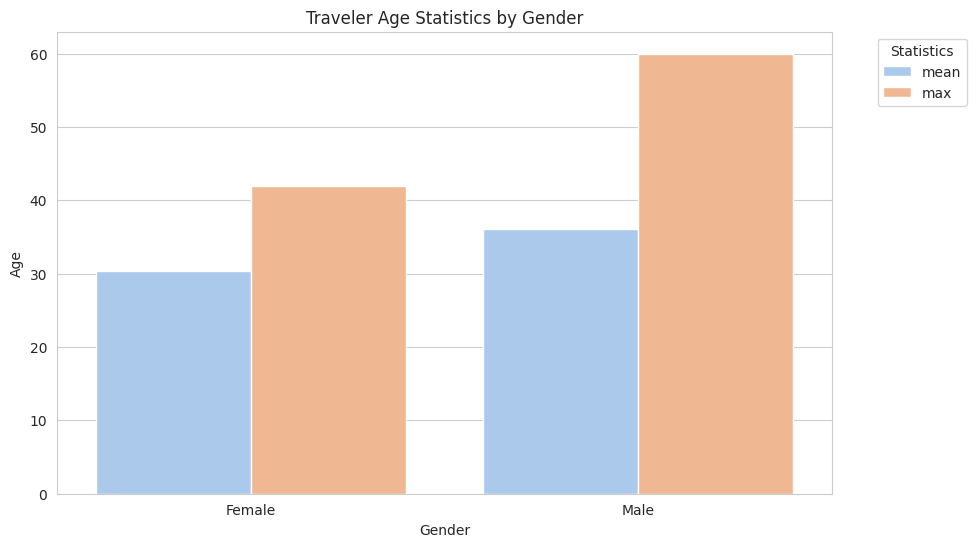

In [ ]:
#Agregasi data
agg_data = df.groupby('Traveler gender')['Traveler age'].agg(['mean','max']).reset_index()

#Meleburkan data agar dapat digunakan di seaborn
melted_data = agg_data.melt(id_vars='Traveler gender', var_name='Statistic', value_name='Age')

#Plot menggunakan seaborn
plt.figure(figsize=(10, 6))
sns.barplot(data=melted_data, x='Traveler gender', y='Age', hue='Statistic')
plt.title('Traveler Age Statistics by Gender')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.legend(title='Statistics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Visualisasi tersebut menampilkan statistik usia traveler berdasarkan jenis kelamin.

**Kesimpulan:**
rata-rata usia traveler laki-laki sedikit lebih tinggi dibandingkan dengan perempuan, serta nilai maksimum usia traveler laki-laki jauh lebih tinggi dibandingkan perempuan.

<Figure size 900x600 with 0 Axes>

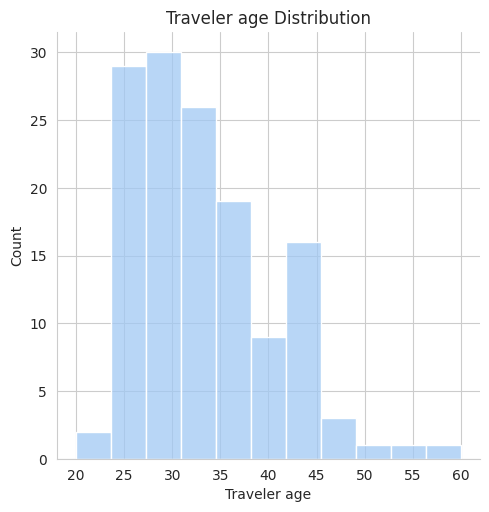

In [ ]:
#Plot distribusi umur penumpang
plt.figure(figsize=(9,6))
sns.displot(x=df['Traveler age']);
plt.xlabel('Traveler age')
plt.title('Traveler age Distribution')
sns.despine();

Visualisasi tersebut merupakan histogram yang menunjukkan distribusi usia para traveler.

**Kesimpulan:**


1. Usia wisatawan terbanyak berada pada rentang 25-30 tahun.
2. Jumlah wisatawan menurun seiring dengan bertambahnya usia.
3. Terdapat sedikit wisatawan yang berusia di bawah 15 tahun dan di atas 60 tahun.

In [ ]:
# Fungsi untuk menentukan kategori umur
def categorize_age(age):
    if age < 30:
        return 'Young'
    elif age >= 30 and age < 60:
        return 'Adult'
    else:
        return 'Elderly'

# Menambahkan kolom kategori umur ke DataFrame
df['Age_category'] = df['Traveler age'].apply(categorize_age)

<Figure size 1000x600 with 0 Axes>

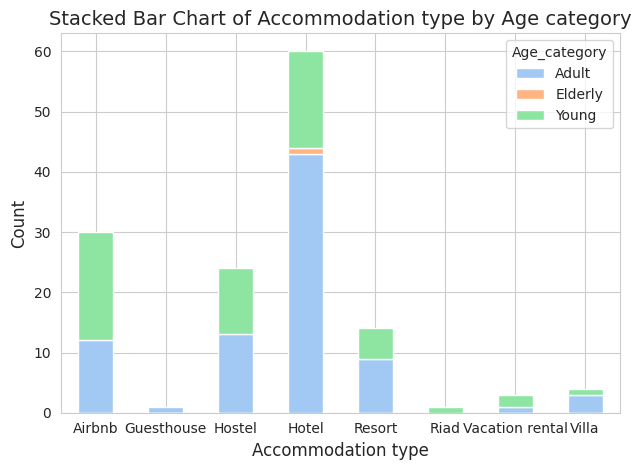

In [ ]:
# Menghitung jumlah observasi untuk setiap kombinasi jenis akomodasi dan kategori umur
count_df = df.groupby(['Accommodation type', 'Age_category']).size().unstack()

# Membuat stacked bar chart
plt.figure(figsize=(10, 6))
count_df.plot(kind='bar', stacked=True)

plt.xlabel('Accommodation type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Stacked Bar Chart of Accommodation type by Age category', fontsize=14)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Visualisasi data yang Anda berikan adalah Stacked Bar Chart yang menunjukkan hubungan antara usia wisatawan dan jenis akomodasi yang mereka pilih.

**Kesimpulan:**
1. Hotel adalah jenis akomodasi yang paling populer di semua kategori usia, dengan jumlah terbanyak untuk kategori dewasa (Adult).
2. Airbnb adalah pilihan akomodasi kedua terpopuler, terutama di kalangan wisatawan muda.
3. Hostel juga cukup populer, dengan mayoritas penggunanya adalah wisatawan muda, diikuti oleh kategori dewasa.
4. Resort menarik minat dari semua kategori usia, namun lebih banyak dipilih oleh wisatawan dewasa dan muda.
5. Guesthouse, riad, vacation rental, dan villa memiliki jumlah pengguna yang lebih sedikit dibandingkan jenis akomodasi lainnya.
6. isatawan lanjut usia (Elderly) memiliki representasi yang lebih kecil di sebagian besar jenis akomodasi, kecuali di hotel di mana mereka memiliki proporsi yang signifikan.
7. komodasi seperti Airbnb dan hostel lebih populer di kalangan wisatawan muda, sementara hotel dan resort menarik minat dari berbagai kelompok usia.

Grafik ini menunjukkan bahwa usia memang mempengaruhi pemilihan jenis akomodasi, dengan perbedaan preferensi yang jelas antara kelompok usia yang berbeda untuk beberapa jenis akomodasi tertentu.

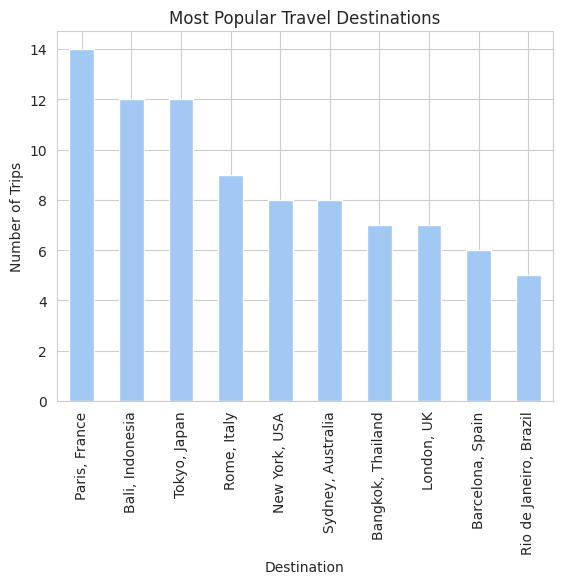

In [ ]:
#Plot 10 destinasi wisata terpopuler
popular_destinations = df['Destination'].value_counts()[:10]
popular_destinations.plot.bar()
plt.title('Most Popular Travel Destinations')
plt.xlabel('Destination')
plt.ylabel('Number of Trips')

plt.show()

Visualisasi data yang Anda berikan adalah grafik batang yang menunjukkan jumlah kunjungan wisatawan ke 10 destinasi wisata terpopuler di dunia.

**Kesimpulan:**
1.   Destinasi wisata terpopuler di dunia adalah Paris, Perancis, dengan jumlah kunjungan wisatawan mencapai 14.
2.   Destinasi wisata terpopuler kedua adalah Bali, Indonesia, dengan jumlah kunjungan wisatawan mencapai 12.
3.   Destinasi wisata terpopuler ketiga adalah Tokyo, Jepang, dengan jumlah kunjungan wisatawan mencapai 10 juta.
4.   Jumlah kunjungan wisatawan ke destinasi wisata lainnya tidak jauh berbeda, dengan rata-rata berkisar antara 2 juta hingga 4 juta.

Grafik batang ini menunjukkan bahwa Paris, Bali, dan Tokyo adalah tiga destinasi wisata terpopuler di dunia. Ketiga destinasi wisata ini memiliki daya tarik tersendiri bagi wisatawan, seperti budaya, sejarah, dan alam.

**Paris** menarik wisatawan dengan sejarah, seni, dan romansa. Kota ini terkenal dengan ikon-ikon seperti Menara Eiffel, Louvre, dan kafe-kafe yang mempesona, memberikan pengalaman budaya yang kaya dan romantis (Sumber: Lonely Planet).

**Bali** menarik dengan keindahan alam, budaya, dan pengalaman relaksasi. Pulau ini menawarkan berbagai atraksi seperti pantai-pantai yang indah, budaya Hindu yang unik dengan pura-pura seperti Pura Luhur Uluwatu, serta berbagai aktivitas seperti selancar, spa, dan yoga (Sumber: Bali.com; Earth Trekkers).

**Tokyo** menarik dengan kombinasi budaya tradisional dan kehidupan kota modern. Tokyo menawarkan berbagai atraksi mulai dari kuil-kuil bersejarah seperti Kuil Sensoji, distrik-distrik belanja yang ramai seperti Shibuya dan Shinjuku, hingga teknologi dan pop culture yang canggih (Sumber: The Broke Backpacker).

Destinasi wisata lainnya tetap memiliki daya tarik dan berkontribusi signifikan dalam industri pariwisata global, meskipun jumlah kunjungan wisatawannya lebih sedikit dibandingkan tiga besar tersebut.

<Figure size 900x600 with 0 Axes>

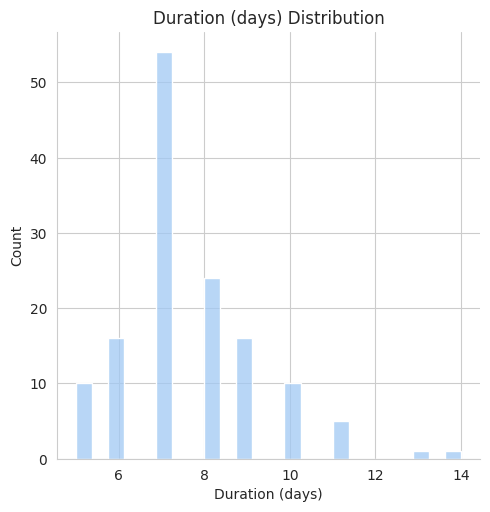

In [ ]:
#Plot distribusi lama perjalanan (hari)
plt.figure(figsize=(9,6))
sns.displot(x=df['Duration (days)']);
plt.xlabel('Duration (days)')
plt.title('Duration (days) Distribution')
sns.despine();

Batang pada grafik menunjukkan jumlah perjalanan dengan durasi yang sesuai dengan label batang.

**Kesimpulan:**
1.   Durasi perjalanan terbanyak adalah 7 hari.
2.   Durasi perjalanan yang populer lainnya adalah 6, 8, dan 9 hari.
3.    Durasi perjalanan yang jarang adalah 5, 11, 12, 13, dan 14 hari.
Kesimpulan

Visualisasi tersebut menunjukkan bahwa durasi perjalanan yang paling umum adalah 7 hari, dengan durasi populer lainnya yaitu 6, 8, dan 9  hari. Durasi perjalanan yang jarang berkisar antara 10 hingga 14 hari.

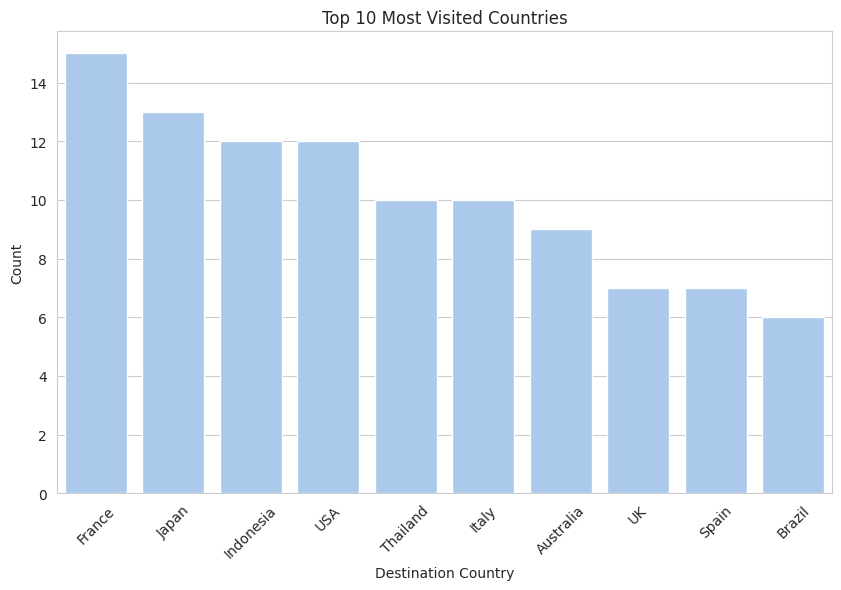

In [ ]:
#Visualisasi top 10 destinasi negara terpopuler dengan plot batang (bar plot)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Destination_Country', order=df['Destination_Country'].value_counts().index[:10])
plt.title('Top 10 Most Visited Countries')
plt.xlabel('Destination Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

"Top 10 Most Visited Countries" menjelaskan bahwa diagram ini menampilkan sepuluh negara yang paling banyak dikunjungi.

**Kesimpulan:**

Prancis adalah negara paling banyak dikunjungi, diikuti oleh Jepang dan Indonesia. Negara-negara di Eropa dan Asia mendominasi daftar ini, sementara Brasil adalah yang paling sedikit dikunjungi di antara sepuluh besar.

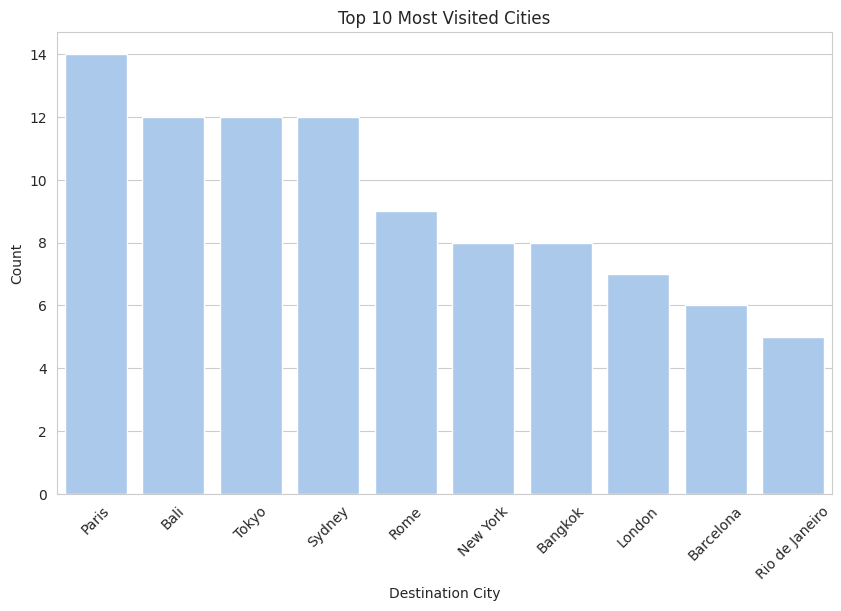

In [ ]:
#Visualisasi top 10 destinasi kota terpopuler dengan plot batang (bar plot)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Destination_City', order=df['Destination_City'].value_counts().index[:10])
plt.title('Top 10 Most Visited Cities')
plt.xlabel('Destination City')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

"Top 10 Most Visited Countries" menjelaskan bahwa diagram ini menampilkan sepuluh negara yang paling banyak dikunjungi.

**Kesimpulan:**
Prancis adalah negara paling banyak dikunjungi, diikuti oleh Jepang dan Indonesia. Negara-negara di Eropa dan Asia mendominasi daftar ini, sementara Brasil adalah yang paling sedikit dikunjungi di antara sepuluh besar.

In [ ]:
# Ekstrak tahun dan bulan dari Start date
df['Year'] = pd.to_datetime(df['Start date']).dt.year
df['Month'] = pd.to_datetime(df['Start date']).dt.strftime('%B')

In [ ]:
# Dapatkan tahun-tahun unik
unique_years = df['Year'].unique()

# Tampilkan hasilnya
unique_years

array([2023, 2024, 2022, 2025, 2021], dtype=int32)

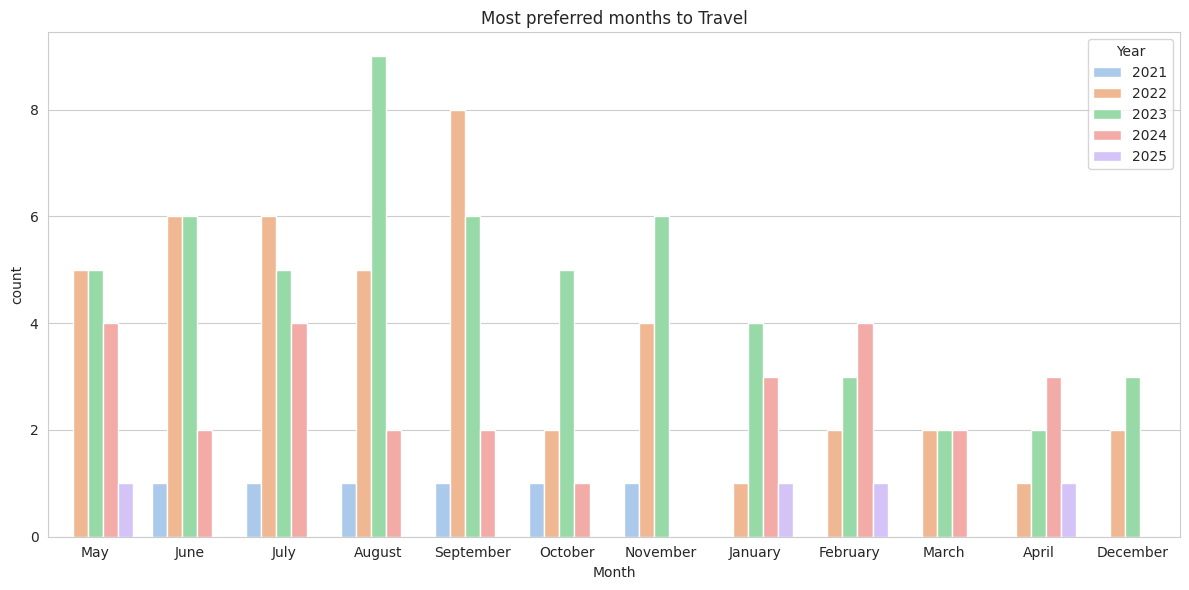

In [ ]:
# Menentukan palet warna berdasarkan jumlah tahun yang unik
palette = sns.color_palette("pastel", len(df['Year'].unique()))

# Membuat plot countplot dengan tambahan year
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Month', hue='Year', palette=palette)
plt.title('Most preferred months to Travel')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

Berdasarkan visualisasi tersebut, bulan-bulan yang paling disukai untuk bepergian adalah **Juni, Juli, Agustus, September**. Hal ini terlihat dari grafik yang menunjukkan bahwa jumlah orang yang bepergian di bulan-bulan tersebut lebih banyak dibandingkan dengan bulan lainnya.

**Beberapa poin penting yang dapat disimpulkan dari visualisasi tersebut:**

1. **Bulan-bulan musim panas (Juni, Juli, dan Agustus) adalah bulan yang paling populer untuk bepergian.** Hal ini kemungkinan karena orang-orang ingin memanfaatkan cuaca yang hangat dan cerah untuk berlibur.

2. **Bulan-bulan musim gugur (September, Oktober, dan November) juga cukup populer untuk bepergian.** Hal ini kemungkinan karena orang-orang ingin menikmati cuaca yang tidak terlalu panas dan tidak terlalu dingin di bulan-bulan tersebut.

**Kesimpulannya, visualisasi tersebut menunjukkan bahwa bulan-bulan yang paling disukai untuk bepergian adalah bulan-bulan di mana cuaca hangat dan cerah.**


In [ ]:
# Calculate daily average accommodation cost per country
df['Accommodation cost per day (IDR)'] = df['Accommodation cost (IDR)'] / df['Duration (days)']


Top 10 Countries with Highest Average Daily Accommodation Cost:
Destination_Country
New Zealand                 16356000.0
Hawaii                       6133500.0
United Arab Emirates    5841428.571429
Canada                  5127476.190476
USA                     4204314.126984
Spain                   3559098.979592
UEA                          3475650.0
France                  3395817.142857
Australia               3252338.787139
South Africa            2642705.555556
Name: Accommodation cost per day (IDR), dtype: Float64


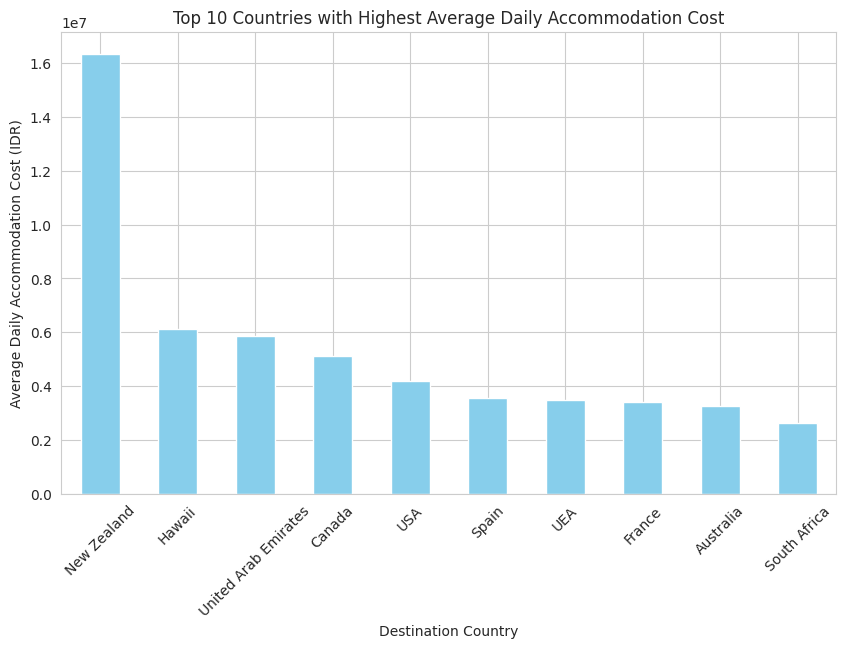

In [ ]:
# Group by destination country and calculate the mean of daily average accommodation cost
avg_daily_cost_per_country = df.groupby('Destination_Country')['Accommodation cost per day (IDR)'].mean().sort_values(ascending=False).head(10)

# Print the top 10 countries with the highest average daily accommodation cost
print("\nTop 10 Countries with Highest Average Daily Accommodation Cost:")
print(avg_daily_cost_per_country)

# Visualize with a bar plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
avg_daily_cost_per_country.plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries with Highest Average Daily Accommodation Cost')
plt.xlabel('Destination Country')
plt.ylabel('Average Daily Accommodation Cost (IDR)')
plt.xticks(rotation=45)
plt.show()

Berdasarkan data yang diberikan, berikut adalah 10 negara dengan biaya akomodasi rata-rata harian tertinggi:

Peringkat	Negara	Biaya Akomodasi Harian (IDR)
1. New Zealand	16,356,000
2. Hawaii	6,133,500
3. United Arab Emirates	5,841,428
4. Canada	5,127,476
5. USA	4,204,314
6. Spain	3,559,098
7. UEA	3,475,650
8. France	3,395,817
9. Australia	3,252,338
10. South Africa	2,642,705

**Kesimpulan:**

Negara-negara di atas memiliki biaya akomodasi rata-rata harian yang cukup tinggi. New Zealand merupakan negara dengan biaya akomodasi termahal, diikuti oleh Hawaii dan Uni Emirat Arab.


Alasan Akomodasi di New Zealand Mahal:

Akomodasi di New Zealand tergolong mahal karena permintaan tinggi dan penawaran terbatas akibat popularitas wisata dan populasi kecil, serta biaya hidup tinggi yang meliputi biaya operasional, pajak, dan standar kualitas akomodasi yang tinggi.


Jenis transportasi yang paling sering digunakan:
Transportation type
Plane         70
Train         38
Car rental    13
Name: count, dtype: int64


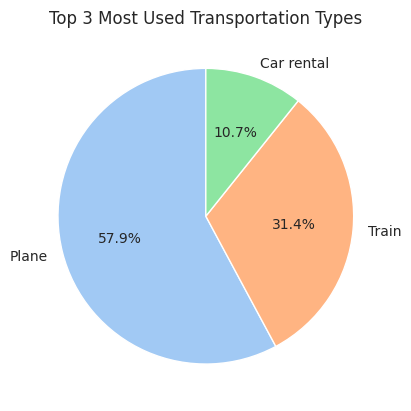

In [ ]:
#Menghitung 3 jenis transportasi paling banyak digunakan
most_used_transportation = df['Transportation type'].value_counts().head(3)
print("\nJenis transportasi yang paling sering digunakan:")
print(most_used_transportation)

# Visualisasi dengan pie chart
most_used_transportation.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Top 3 Most Used Transportation Types')
plt.ylabel('')
plt.show()


"Top 3 Most Used Transportation Types" menjelaskan bahwa diagram ini menampilkan tiga jenis transportasi yang paling banyak digunakan oleh orang-orang.

**Kesimpulan:**
1.   Pesawat terbang adalah moda transportasi paling populer, digunakan dalam lebih dari setengah dari semua perjalanan.
2.   Kereta api juga merupakan pilihan transportasi yang signifikan, digunakan dalam lebih dari sepertiga perjalanan.
3.   Penerbangan, dalam konteks yang mungkin berbeda dari pesawat terbang biasa, digunakan dalam proporsi yang lebih kecil tetapi tetap penting.

Diagram ini memberikan gambaran tentang preferensi orang-orang dalam menggunakan berbagai jenis transportasi untuk perjalanan mereka, dengan pesawat terbang sebagai pilihan utama, diikuti oleh kereta api.

Accommodation type
Hotel     60
Airbnb    30
Hostel    24
Resort    14
Villa      4
Name: count, dtype: int64


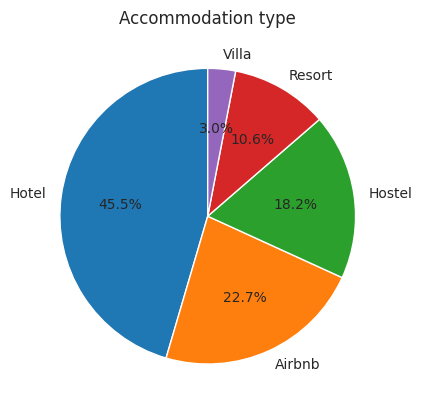

In [ ]:
#Menghitung nilai frekuensi dan ambil 5 teratas
a = df['Accommodation type'].value_counts().sort_values(ascending=False).head(5)
print(a)

#Plot pie chart dengan palet warna yang berbeda
colors = plt.cm.tab10.colors[:len(a)]  #Palet warna 'tab10'

a.plot(kind='pie', autopct='%0.1f%%', startangle=90, colors=colors)
plt.ylabel('')
plt.title('Accommodation type')
plt.show()

diagram lingkaran (pie chart) yang menggambarkan distribusi persentase berbagai jenis akomodasi yang digunakan.

**Kesimpulan:**
diagram lingkaran menunjukkan bahwa hotel adalah jenis akomodasi yang paling populer dengan 45.5% pengguna, diikuti oleh Airbnb dengan 22.7%, hostel dengan 18.2%, resort dengan 10.6%, dan villa dengan 3.0%. Hal ini menunjukkan bahwa mayoritas orang lebih memilih hotel, sementara Airbnb dan hostel juga cukup populer, sedangkan resort dan villa lebih jarang digunakan.


Traveler dari negara American yang paling sering bepergian.

Negara yang paling sering dikunjungi oleh traveler dari negara tersebut:
Destination_Country
France    7
USA       6
Japan     4
Name: count, dtype: int64


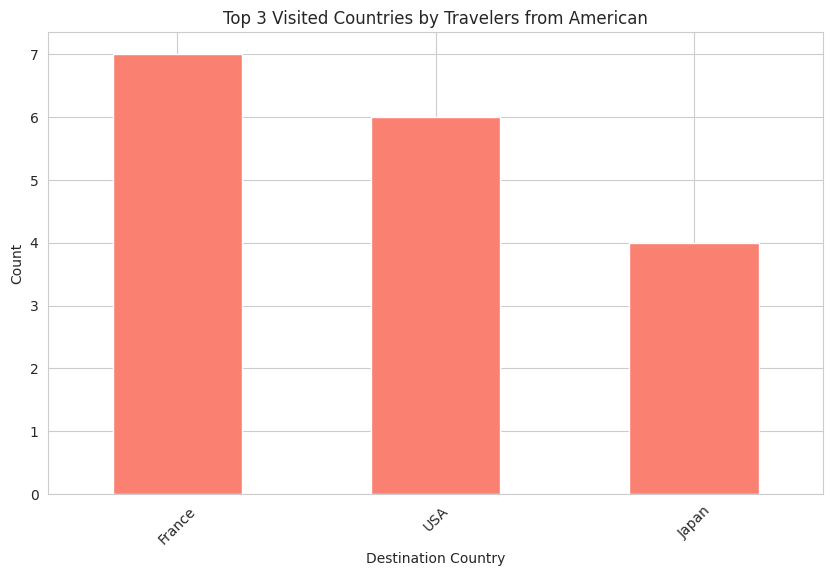

In [ ]:
#Mengambil negara dengan traveler yang paling sering berpergian
most_traveling_nationality = df['Traveler nationality'].value_counts().idxmax()

#Filter data untuk traveler dari negara yang paling sering bepergian
most_traveling_country_data = df[df['Traveler nationality'] == most_traveling_nationality]

#Menghitung kunjungan ke setiap negara
most_visited_countries_by_nationality = most_traveling_country_data['Destination_Country'].value_counts().head(3)

print(f"\nTraveler dari negara {most_traveling_nationality} yang paling sering bepergian.")
print("\nNegara yang paling sering dikunjungi oleh traveler dari negara tersebut:")
print(most_visited_countries_by_nationality)

#Visualisasi dengan bar plot untuk top 3 negara
plt.figure(figsize=(10, 6))
most_visited_countries_by_nationality.plot(kind='bar', color='salmon')
plt.title(f"Top 3 Visited Countries by Travelers from {most_traveling_nationality}")
plt.xlabel('Destination Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


grafik batang yang menunjukkan tiga negara yang paling sering dikunjungi oleh wisatawan dari Amerika.

**Kesimpulan:**
menunjukkan bahwa **wisatawan Amerika** paling sering **mengunjungi Prancis**, diikuti oleh perjalanan **domestik di dalam USA sendiri**, dan kemudian **Jepang**. Hal ini mengindikasikan popularitas Prancis sebagai destinasi wisata internasional utama bagi orang Amerika, sementara Jepang juga merupakan tujuan yang cukup populer di Asia.


In [ ]:
#Trip Id and Desitination doesn't have much significance. As Trip Id is similar as index values.
#Destination values we have segregated in two different columns
#So, dropping the 'Trip ID' and 'Destination' columns from the dataframes
df.drop(['Destination','Destination_City','Destination_Country','Trip ID', 'Traveler name','Traveler gender','Traveler nationality','Accommodation type','Transportation type', 'Day of the week','Month','Age_category'],axis=1,inplace=True)

In [ ]:
df

,Start date,End date,Duration (days),Traveler age,Accommodation cost (IDR),Transportation cost (IDR),Year,Accommodation cost per day (IDR)
0,2023-05-01,2023-05-08,7,35,19627200,9813600,2023,2803885.714286
1,2023-06-15,2023-06-20,5,28,13084800,8178000,2023,2616960.0
2,2023-07-01,2023-07-08,7,45,16356000,11449200,2023,2336571.428571
3,2023-08-15,2023-08-29,14,29,32712000,16356000,2023,2336571.428571
4,2023-09-10,2023-09-17,7,26,11449200,3271200,2023,1635600.0
5,2023-10-05,2023-10-10,5,42,24534000,13084800,2023,4906800.0
6,2023-11-20,2023-11-30,10,33,8178000,19627200,2023,817800.0
7,2024-01-05,2024-01-12,7,25,14720400,9813600,2024,2102914.285714
8,2024-02-14,2024-02-21,7,31,19627200,3271200,2024,2803885.714286
9,2024-03-10,2024-03-17,7,39,40890000,13084800,2024,5841428.571429


<Axes: >

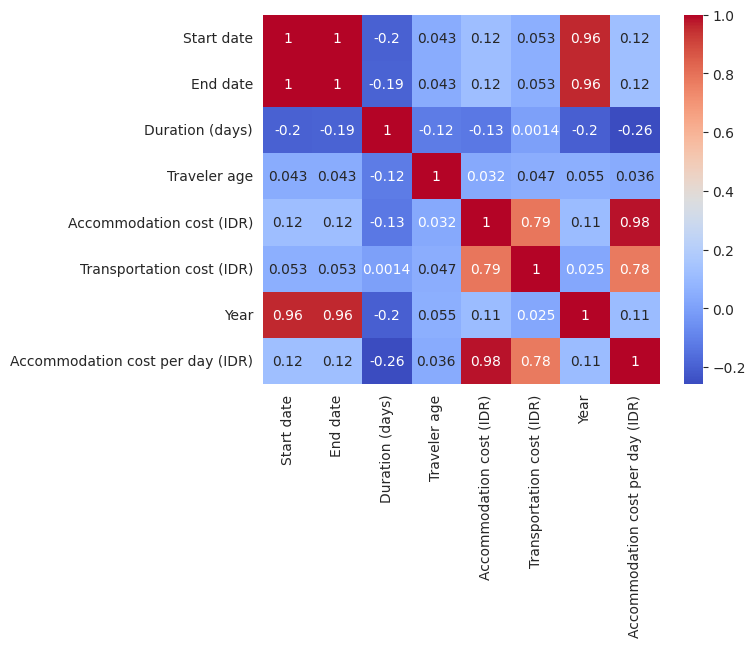

In [ ]:
sns.set_style('whitegrid')
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

1. Start date dan End date (1.0):
   Korelasi sempurna ini menunjukkan bahwa tanggal mulai dan selesai perjalanan selalu bergerak bersama. Ini logis karena perubahan tanggal mulai akan selalu mempengaruhi tanggal selesai dengan cara yang sama.

2. Accommodation cost dan Transportation cost (0.79):
   Korelasi kuat positif ini mengindikasikan bahwa saat biaya akomodasi meningkat, biaya transportasi juga cenderung meningkat. Ini mungkin mencerminkan perbedaan harga antar destinasi atau level kemewahan perjalanan.

Secara keseluruhan, data ini menunjukkan bahwa kebanyakan aspek perjalanan cukup independen satu sama lain, dengan pengecualian utama pada hubungan antara biaya akomodasi dan transportasi.